In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

# SFR

In [2]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

In [3]:
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
# stirfo_mdp = STIRFutureOptionMDP(source="STIRFO_DUAL-QL")

In [12]:
as_of = datetime.date(2026, 3, 6)

out = stirfo_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["SFRU27|50DP"],
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
	# "force_refresh": True
})

p = next(iter(out.values()))[0]
print("price:", p.price())
print("iv_normal_bps:", p.iv_normal_bps())
print("delta/gamma/vega/theta:", p.delta(), p.gamma(), p.vega(), p.theta())

price: 0.4625
iv_normal_bps: 93.10883107423138
delta/gamma/vega/theta: -0.49263853854963635 0.32852635063118396 0.46763005759640436 -0.12660307157963432


In [13]:
# smile = stirfo_mdp.fetch_sabr_smile(
#     {
#         "symbol": "SFRU27",
#         "as_of": as_of,
#         # "force_refresh": True,
#         "show_tqdm": True,
#     }
# )
# smile
# 
smiles = stirfo_mdp.fetch_bulk_sabr_smile(
	{
		"symbols": ["SFRU27"],
		"timestamps": [
			datetime.date(2026, 2, 25),
			datetime.date(2026, 3, 6),
			# datetime.date(2026, 3, 5),
		],
		# "force_refresh": True,
		"show_tqdm": True,
	}
)
smiles

{'SFRU27': {datetime.date(2026, 2, 25): STIRFutureOptionSABRSmile(source='BARCHART_STIRFO-QL', symbol='SFRU27', underlying_contract='SFRU27', quote_timestamp=datetime.datetime(2026, 2, 25, 17, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))), params=STIRFutureOptionSABRParams(alpha=0.07501045034282527, beta=0.5, rho=0.2110703848869428, nu=0.6615504301948829, forward_price=96.925, forward_rate=3.075000000000003, time_to_expiry=1.5534246575342465, expiry_date=datetime.date(2027, 9, 15), as_of=datetime.date(2026, 2, 25)), points=(STIRFutureOptionSmilePoint(label='SFRU27|5DP', right='P', delta_abs=5.0, strike_price=94.9705625378904, strike_rate=5.029437462109598, iv_normal_price=0.9533435320972435, iv_normal_bps=95.33435320972436), STIRFutureOptionSmilePoint(label='SFRU27|10DP', right='P', delta_abs=10.0, strike_price=95.51556403933327, strike_rate=4.48443596066673, iv_normal_price=0.8823972892643905, iv_normal_bps=88.23972892643906), STIRFutureOptionSmilePoint(labe

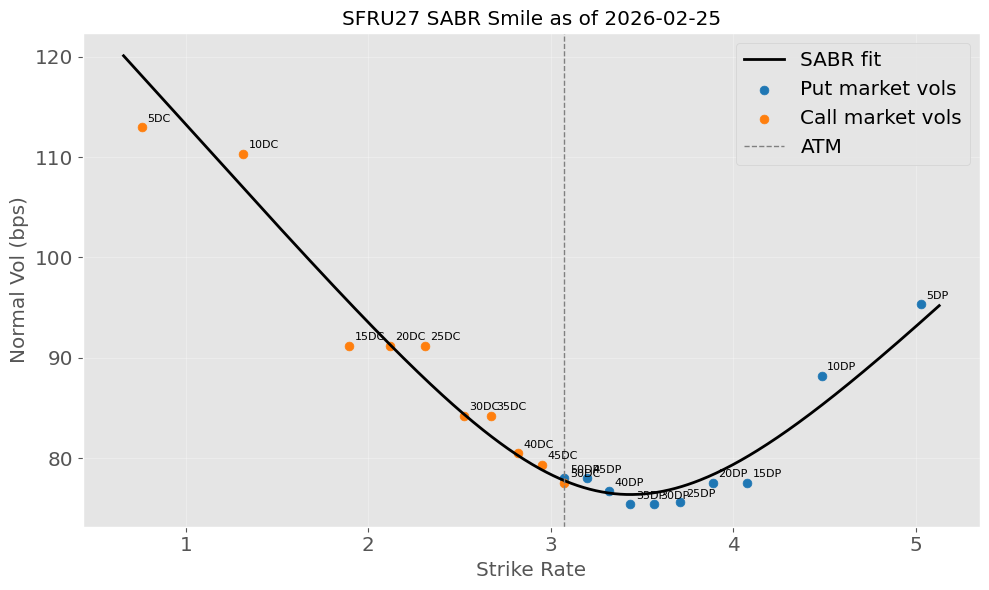

In [19]:
smile = smiles["SFRU27"][datetime.date(2026, 2, 25)]

pts = sorted(smile.points, key=lambda p: p.strike_rate)
call_pts = [p for p in pts if p.right == "C"]
put_pts = [p for p in pts if p.right == "P"]

# Smooth strike grid in rate space
x_min = min(p.strike_rate for p in pts) - 0.10
x_max = max(p.strike_rate for p in pts) + 0.10
strike_grid = np.linspace(x_min, x_max, 400)

# Model vols from fitted SABR smile
sabr_vols_bps = smile.normal_vol(
    strike_grid,
    strike_space="rate",
    vol_units="bps",
)

fig, ax = plt.subplots(figsize=(10, 6))

# Smooth SABR curve
ax.plot(
    strike_grid,
    sabr_vols_bps,
    color="black",
    lw=2,
    label="SABR fit",
)

# Market vols
ax.scatter(
    [p.strike_rate for p in put_pts],
    [p.iv_normal_bps for p in put_pts],
    color="tab:blue",
    s=40,
    label="Put market vols",
)
ax.scatter(
    [p.strike_rate for p in call_pts],
    [p.iv_normal_bps for p in call_pts],
    color="tab:orange",
    s=40,
    label="Call market vols",
)

ax.axvline(
    smile.params.forward_rate,
    color="gray",
    ls="--",
    lw=1,
    label="ATM",
)

for p in pts:
    ax.annotate(
        p.label.split("|")[-1],
        (p.strike_rate, p.iv_normal_bps),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(f"{smile.symbol} SABR Smile as of {smile.params.as_of}")
ax.set_xlabel("Strike Rate")
ax.set_ylabel("Normal Vol (bps)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# USTS

In [17]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP
from MDP.USTFutures.USTFuturesMDP import USTFuturesMDP

In [20]:
ustf_mdp = USTFuturesMDP(source="BARCHART_USTF-RL")
ustfo_bc_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
ustfo_qs_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

In [26]:
as_of = datetime.date(2026, 3, 6)

out = ustfo_bc_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TYM26|ATMS"],  
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
	# "force_refresh": True
})

pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 3/3 [00:00<00:00,  9.04it/s]

resolved_symbol: ZNM26|1125S
price: 2.125 iv_normal_bps: 86.81949213671156
delta: -0.018436644925305667 gamma: 0.2949329841724009 vega: 0.3635149510538741 theta: -4.954960086169665


In [ ]:
ustfo_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

with ustfo_mdp:
	smile = ustfo_mdp.fetch_bulk_sabr_smile(
		{
			"globex_symbols": ["TY_05"],
			"timestamps": [
                datetime.date(2026, 3, 3),
                datetime.date(2026, 3, 4),
                # datetime.date(2026, 3, 5),
            ],
			# "force_refresh": True,
	        "show_tqdm": True,
		}
	)
	# smile = ustfo_mdp.fetch_sabr_smile(
	# 	{
	# 		"globex_symbol": "TY_05",
	# 		"as_of": datetime.date(2026, 3, 4),
	# 		# "force_refresh": True,
	# 	}
	# )

smile